# Machine Learning Models for Early Player Retention Prediction

## Objective

This notebook develops and evaluates multiple supervised machine learning models to predict early player retention using behavioural features engineered from the first 24 hours of gameplay.

Three classification algorithms are evaluated:

- Logistic Regression (Baseline Model)
- Random Forest
- XGBoost

The models are compared using multiple evaluation metrics including Accuracy, Precision, Recall, F1-score, ROC-AUC, and Confusion Matrix analysis. The best-performing model will subsequently be used for explainability analysis using SHAP.

In [25]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import (
    StandardScaler,
    LabelEncoder
)

In [26]:
# Load analytical dataset

df = pd.read_csv("../data/player_features_final.csv")

print(f"Dataset Shape: {df.shape}")

df.head()

Dataset Shape: (11080, 31)


,pid,age,gender,country,login_count_24h,repeat_login_count_24h,active_days_24h,avg_login_gap_minutes,jobs_started_24h,unique_jobs_started_24h,...,jobs_exited_24h,avg_session_length_exit,max_session_length_exit,avg_session_length,max_session_length,career_play_ratio,special_play_ratio,freeplay_ratio,challenge_ratio,retained
0,p126,29.0,Male,USA,0,0,0,0.0,0,0,...,0,0.0,0,0.0,0,0.0,0.0,0.0,0.0,0
1,p1317,35.0,Male,USA,0,0,0,0.0,0,0,...,0,0.0,0,0.0,0,0.0,0.0,0.0,0.0,0
2,p1661,18.0,Male,USA,0,0,0,0.0,0,0,...,0,0.0,0,0.0,0,0.0,0.0,0.0,0.0,0
3,p3338,24.0,Female,USA,0,0,0,0.0,0,0,...,0,0.0,0,0.0,0,0.0,0.0,0.0,0.0,0
4,p10095,32.0,Female,UK,1,0,1,0.0,1,1,...,2,106.5,155,58.0,58,1.0,0.0,0.0,0.0,0


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11080 entries, 0 to 11079
Data columns (total 31 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   pid                           11080 non-null  object 
 1   age                           10964 non-null  float64
 2   gender                        11018 non-null  object 
 3   country                       10670 non-null  object 
 4   login_count_24h               11080 non-null  int64  
 5   repeat_login_count_24h        11080 non-null  int64  
 6   active_days_24h               11080 non-null  int64  
 7   avg_login_gap_minutes         11080 non-null  float64
 8   jobs_started_24h              11080 non-null  int64  
 9   unique_jobs_started_24h       11080 non-null  int64  
 10  career_jobs_started_24h       11080 non-null  int64  
 11  special_jobs_started_24h      11080 non-null  int64  
 12  freeplay_jobs_started_24h     11080 non-null  int64  
 13  c

In [28]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,10964.0,28.251186,8.813566,18.0,21.0,27.000000,33.000,118.000000
login_count_24h,11080.0,1.013177,1.142365,0.0,0.0,1.000000,1.000,23.000000
repeat_login_count_24h,11080.0,0.384116,0.886928,0.0,0.0,0.000000,0.000,22.000000
active_days_24h,11080.0,0.728339,0.629645,0.0,0.0,1.000000,1.000,2.000000
avg_login_gap_minutes,11080.0,109.310749,263.815408,0.0,0.0,0.000000,0.000,1424.950000
jobs_started_24h,11080.0,2.409296,4.545791,0.0,0.0,1.000000,3.000,100.000000
unique_jobs_started_24h,11080.0,2.318682,3.970758,0.0,0.0,1.000000,3.000,60.000000
career_jobs_started_24h,11080.0,2.207220,3.793028,0.0,0.0,1.000000,3.000,76.000000
special_jobs_started_24h,11080.0,0.100361,0.477341,0.0,0.0,0.000000,0.000,10.000000
freeplay_jobs_started_24h,11080.0,0.074549,1.139610,0.0,0.0,0.000000,0.000,60.000000


In [29]:
df["retained"].value_counts()

retained
1    5570
0    5510
Name: count, dtype: int64

## Correlation Analysis

Before model development, a correlation analysis was performed to examine relationships among the engineered numerical features.

The objective was to identify potential multicollinearity and better understand the behavioural relationships within the engineered feature set. The correlation analysis serves as an exploratory diagnostic rather than a feature selection criterion, as tree-based machine learning algorithms are generally robust to correlated predictors.

In [30]:
numerical_features = df.select_dtypes(include=["number"])

numerical_features.head()

,age,login_count_24h,repeat_login_count_24h,active_days_24h,avg_login_gap_minutes,jobs_started_24h,unique_jobs_started_24h,career_jobs_started_24h,special_jobs_started_24h,freeplay_jobs_started_24h,...,jobs_exited_24h,avg_session_length_exit,max_session_length_exit,avg_session_length,max_session_length,career_play_ratio,special_play_ratio,freeplay_ratio,challenge_ratio,retained
0,29.0,0,0,0,0.0,0,0,0,0,0,...,0,0.0,0,0.0,0,0.0,0.0,0.0,0.0,0
1,35.0,0,0,0,0.0,0,0,0,0,0,...,0,0.0,0,0.0,0,0.0,0.0,0.0,0.0,0
2,18.0,0,0,0,0.0,0,0,0,0,0,...,0,0.0,0,0.0,0,0.0,0.0,0.0,0.0,0
3,24.0,0,0,0,0.0,0,0,0,0,0,...,0,0.0,0,0.0,0,0.0,0.0,0.0,0.0,0
4,32.0,1,0,1,0.0,1,1,1,0,0,...,2,106.5,155,58.0,58,1.0,0.0,0.0,0.0,0


In [31]:
correlation_matrix = numerical_features.corr()

correlation_matrix.head()

,age,login_count_24h,repeat_login_count_24h,active_days_24h,avg_login_gap_minutes,jobs_started_24h,unique_jobs_started_24h,career_jobs_started_24h,special_jobs_started_24h,freeplay_jobs_started_24h,...,jobs_exited_24h,avg_session_length_exit,max_session_length_exit,avg_session_length,max_session_length,career_play_ratio,special_play_ratio,freeplay_ratio,challenge_ratio,retained
age,1.000000,0.078742,0.066081,0.069260,0.044051,0.030446,0.035571,0.039259,-0.010820,0.000142,...,0.037391,0.085556,0.097482,0.064808,0.082355,0.062559,-0.011710,0.002071,-0.008288,0.117064
login_count_24h,0.078742,1.000000,0.917037,0.776848,0.504048,0.457883,0.481036,0.489292,0.213751,0.090487,...,0.543325,0.164361,0.274443,0.141224,0.241731,0.589476,0.112473,0.109377,0.056847,0.315977
repeat_login_count_24h,0.066081,0.917037,1.000000,0.516753,0.475908,0.377831,0.386303,0.397492,0.189290,0.090883,...,0.468664,0.088734,0.185429,0.086572,0.170230,0.323740,0.061363,0.098698,0.050450,0.268553
active_days_24h,0.069260,0.776848,0.516753,1.000000,0.591294,0.432093,0.473702,0.473241,0.175709,0.054516,...,0.481099,0.216777,0.316164,0.174223,0.274102,0.739228,0.133245,0.086459,0.050576,0.295912
avg_login_gap_minutes,0.044051,0.504048,0.475908,0.591294,1.000000,0.301387,0.333277,0.333347,0.106323,0.033873,...,0.339166,0.127847,0.214150,0.114272,0.200350,0.330146,0.038416,0.051569,0.042393,0.251568


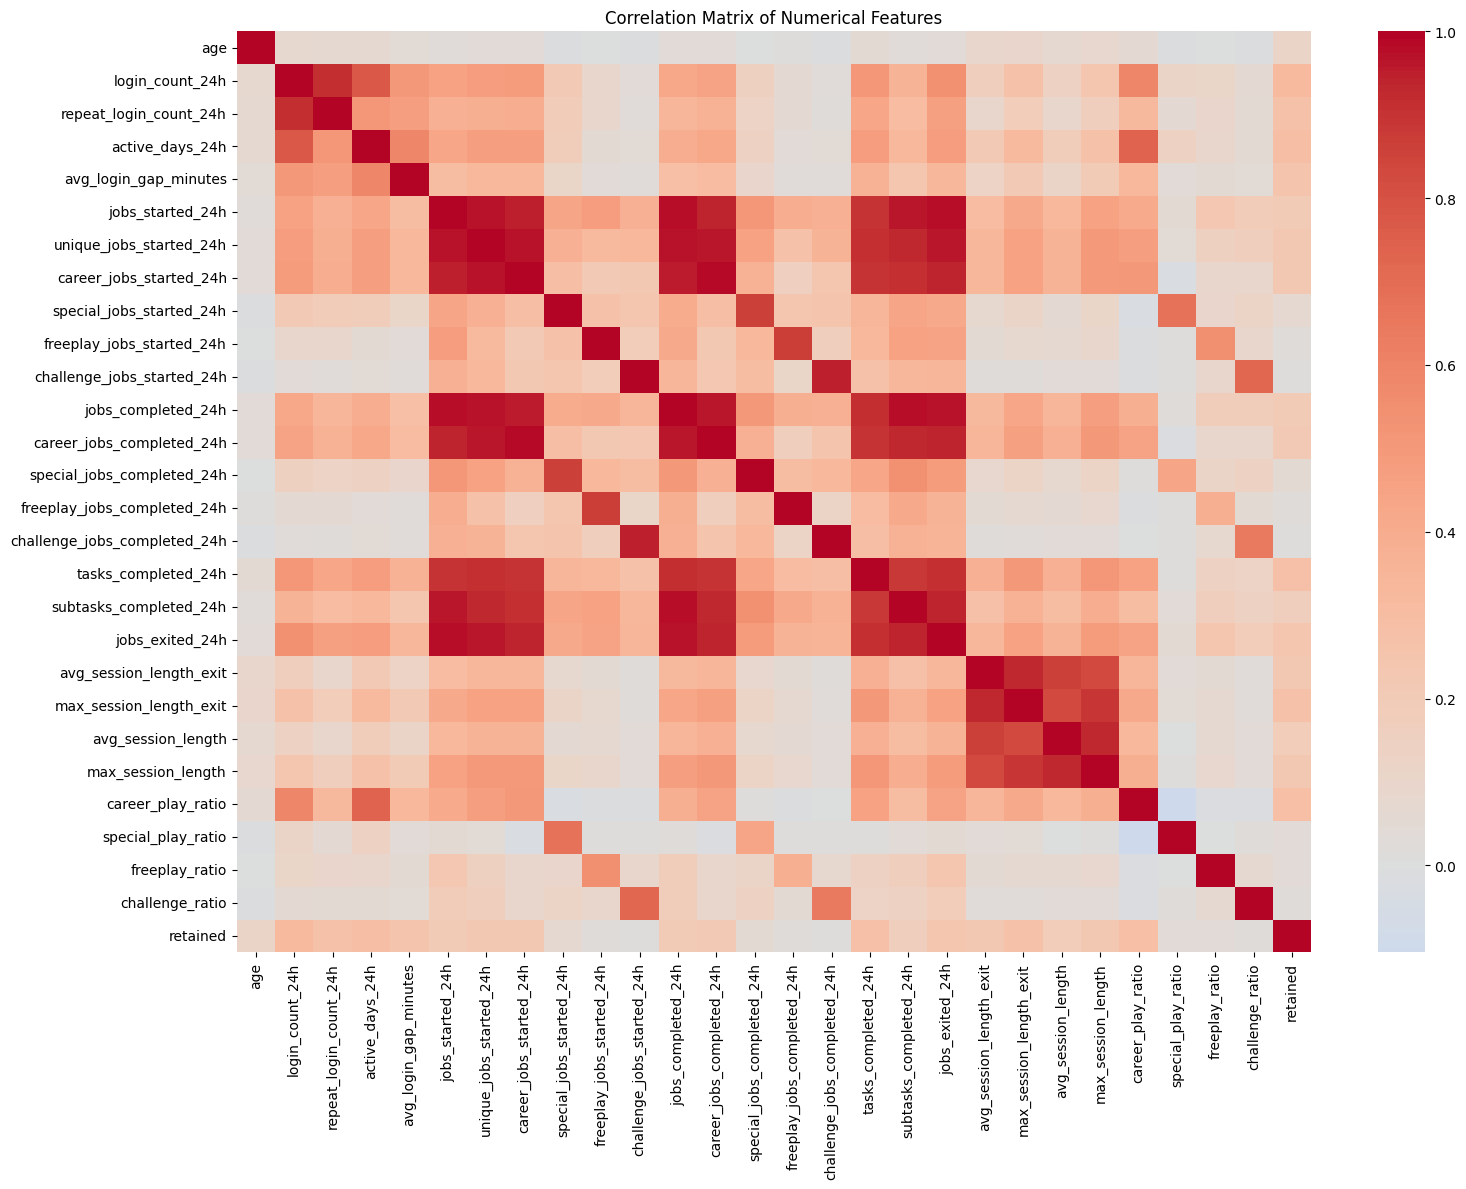

In [32]:
import seaborn as sns

plt.figure(figsize=(16, 12))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Numerical Features")

plt.tight_layout()

plt.show()

In [33]:
# Compute correlation matrix
correlation_matrix = numerical_features.corr().abs()

# Keep only the upper triangle to avoid duplicate pairs
upper_triangle = correlation_matrix.where(
    np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool)
)

# Extract highly correlated feature pairs
high_corr = (
    upper_triangle.stack()
    .reset_index()
)

high_corr.columns = [
    "Feature 1",
    "Feature 2",
    "Correlation"
]

# Filter correlations >= 0.80
high_corr = (
    high_corr[high_corr["Correlation"] >= 0.90]
    .sort_values(
        by="Correlation",
        ascending=False
    )
    .reset_index(drop=True)
)

high_corr

,Feature 1,Feature 2,Correlation
0,career_jobs_started_24h,career_jobs_completed_24h,0.989696
1,jobs_started_24h,jobs_completed_24h,0.981974
2,jobs_started_24h,jobs_exited_24h,0.980550
3,jobs_completed_24h,subtasks_completed_24h,0.977173
4,unique_jobs_started_24h,jobs_completed_24h,0.969838
5,unique_jobs_started_24h,career_jobs_started_24h,0.969827
6,jobs_completed_24h,jobs_exited_24h,0.967275
7,jobs_started_24h,unique_jobs_started_24h,0.967052
8,jobs_completed_24h,career_jobs_completed_24h,0.964201
9,jobs_started_24h,subtasks_completed_24h,0.961919


In [24]:
(
    df["unique_jobs_started_24h"] ==
    df["distinct_jobs_played"]
).all()

True